In [12]:
!pip install transformers

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
from transformers import SegformerForSemanticSegmentation

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [14]:
class MagneticTilesDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, img_size=(256, 256)):
        self.transform = transform
        self.img_size  = img_size
        self.pairs     = []

        classes = ['MT_Blowhole', 'MT_Break', 'MT_Crack', 'MT_Fray', 'MT_Free', 'MT_Uneven']

        # Structure: root_dir/split/MT_*/Imgs/*.jpg  &  root_dir/split/MT_*/GTs/*.png
        for cls in classes:
            imgs_dir = os.path.join(root_dir, split, cls, 'Imgs')
            gts_dir  = os.path.join(root_dir, split, cls, 'GTs')
            if not os.path.isdir(imgs_dir) or not os.path.isdir(gts_dir):
                print(f"Warning: {imgs_dir} or {gts_dir} not found, skipping.")
                continue
            gt_files  = set(os.listdir(gts_dir))
            jpg_files = sorted([f for f in os.listdir(imgs_dir) if f.endswith('.jpg')])
            for jpg in jpg_files:
                base = os.path.splitext(jpg)[0]
                png  = base + '.png'
                if png in gt_files:
                    self.pairs.append((
                        os.path.join(imgs_dir, jpg),
                        os.path.join(gts_dir,  png)
                    ))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, gt_path = self.pairs[idx]

        img   = Image.open(img_path).convert('RGB')
        label = Image.open(gt_path).convert('L')

        img   = img.resize(self.img_size)
        label = label.resize(self.img_size)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        label = transforms.ToTensor()(label)
        label = (label > 0.5).float()

        return img, label


In [15]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()


In [16]:
def dice_coef(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    denom = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (denom + smooth)
    return dice.mean()

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        dice = dice_coef(pred, target, smooth=self.smooth)
        return 1.0 - dice

def combined_loss(logits, mask, bce_weight=0.6, dice_weight=0.4):
    bce_loss = nn.BCEWithLogitsLoss()
    bce = bce_loss(logits, mask)
    probs = torch.sigmoid(logits)
    dice = DiceLoss()(probs, mask)
    return bce_weight * bce + dice_weight * dice


In [17]:
@torch.no_grad()
def compute_metrics_batch(logits, masks, thresh=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thresh).float()
    preds_flat = preds.view(-1).cpu().numpy()
    masks_flat = masks.view(-1).cpu().numpy()
    
    unique_preds = np.unique(preds_flat)
    unique_masks = np.unique(masks_flat)
    
    if len(unique_preds) == 1 and len(unique_masks) == 1:
        if unique_preds[0] == unique_masks[0]:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = len(preds_flat), 0, 0, 0
            else:
                tp, fp, fn, tn = 0, 0, 0, len(preds_flat)
        else:
            if unique_preds[0] == 1:
                tp, fp, fn, tn = 0, len(preds_flat), 0, 0
            else:
                tp, fp, fn, tn = 0, 0, len(preds_flat), 0
    else:
        cm = confusion_matrix(masks_flat, preds_flat, labels=[0,1])
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            if cm.shape == (1, 1):
                if unique_masks[0] == 0:
                    tn, fp, fn, tp = cm[0,0], 0, 0, 0
                else:
                    tn, fp, fn, tp = 0, 0, 0, cm[0,0]
            else:
                tn, fp, fn, tp = 0, 0, 0, 0
    
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    miou = (iou + iou_bg) / 2
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "iou": float(iou), "miou": float(miou), "dice": float(dice), "precision": float(precision),
            "recall": float(recall), "f1": float(f1), "acc": float(acc)}


In [18]:
def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    for imgs, masks in tqdm(loader, desc="Train batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()

        outputs = model(pixel_values=imgs)
        logits = outputs.logits  # (B, 1, H/4, W/4)
        logits = F.interpolate(logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)

        loss = combined_loss(logits, masks)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        
        metrics = compute_metrics_batch(logits, masks)
        running_acc += metrics['acc'] * imgs.size(0)
    
    if scheduler is not None:
        scheduler.step()
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_acc / len(loader.dataset)
    return epoch_loss, epoch_acc

@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    agg = {"tn":0,"fp":0,"fn":0,"tp":0}
    
    for imgs, masks in tqdm(loader, desc="Val batch"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(pixel_values=imgs)
        logits = outputs.logits  # (B, 1, H/4, W/4)
        logits = F.interpolate(logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)

        loss = combined_loss(logits, masks)
        running_loss += loss.item() * imgs.size(0)
        metas = compute_metrics_batch(logits, masks)
        for k in ["tn","fp","fn","tp"]:
            agg[k] += metas[k]
    
    tp, fp, fn, tn = agg["tp"], agg["fp"], agg["fn"], agg["tn"]
    eps = 1e-8
    iou = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    miou = (iou + iou_bg) / 2
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    
    epoch_loss = running_loss / len(loader.dataset)
    metrics = {"loss": epoch_loss, "iou": iou, "miou": miou, "dice": dice, "precision": precision,
               "recall": recall, "f1": f1, "acc": acc, 
               "confusion": np.array([[tn, fp], [fn, tp]])}
    return metrics


In [19]:
def plot_confusion_matrix(confusion_matrix, title='Confusion Matrix'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Defect', 'Defect'], 
                yticklabels=['No Defect', 'Defect'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{title.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [20]:
def train_model(model, train_loader, val_loader, num_epochs=200, learning_rate=2e-4, patience=10):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or name.endswith(".bias"):
            no_decay.append(p)
        else:
            decay.append(p)

    optimizer = optim.AdamW(
        [
            {"params": decay, "weight_decay": 1e-4},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=learning_rate,
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.7, patience=7, min_lr=1e-6
    )
    
    early_stopping = EarlyStopping(patience=patience, min_delta=1e-4)
    
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    val_ious = []
    val_dices = []
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_metrics = validate(model, val_loader)
        
        scheduler.step(val_metrics['loss'])
        
        print(f"Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.6f} | Val Acc: {val_metrics['acc']:.4f} | IoU: {val_metrics['iou']:.4f} | Dice: {val_metrics['dice']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_metrics['loss'])
        val_accs.append(val_metrics['acc'])
        val_ious.append(val_metrics['iou'])
        val_dices.append(val_metrics['dice'])
        
        if val_metrics['loss'] < best_val_loss - 1e-4:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'best_segformer_mt.pth')
            print(f"Saved best model with validation loss: {best_val_loss:.6f}")
        
        if early_stopping(val_metrics['loss'], model):
            print(f'Early stopping triggered after {epoch+1} epochs')
            break
    
    return train_losses, train_accs, val_losses, val_accs, val_ious, val_dices


Training samples: 2249
Validation samples: 268
Test samples: 271


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

...

Train Loss: 0.154720 | Train Acc: 0.9954
Val Loss: 0.323492 | Val Acc: 0.9952 | IoU: 0.8451 | Dice: 0.9161 | F1: 0.9161
Learning Rate: 1.40e-04

Epoch 20/200


Val batch: 100%|██████████| 134/134 [00:03<00:00, 42.69it/s]


Train Loss: 0.152202 | Train Acc: 0.9958
Val Loss: 0.321642 | Val Acc: 0.9949 | IoU: 0.8370 | Dice: 0.9113 | F1: 0.9113
Learning Rate: 1.40e-04

Epoch 21/200


Val batch: 100%|██████████| 134/134 [00:03<00:00, 41.76it/s]


Train Loss: 0.151892 | Train Acc: 0.9959
Val Loss: 0.322881 | Val Acc: 0.9950 | IoU: 0.8385 | Dice: 0.9122 | F1: 0.9122
Learning Rate: 1.40e-04
Early stopping triggered after 21 epochs


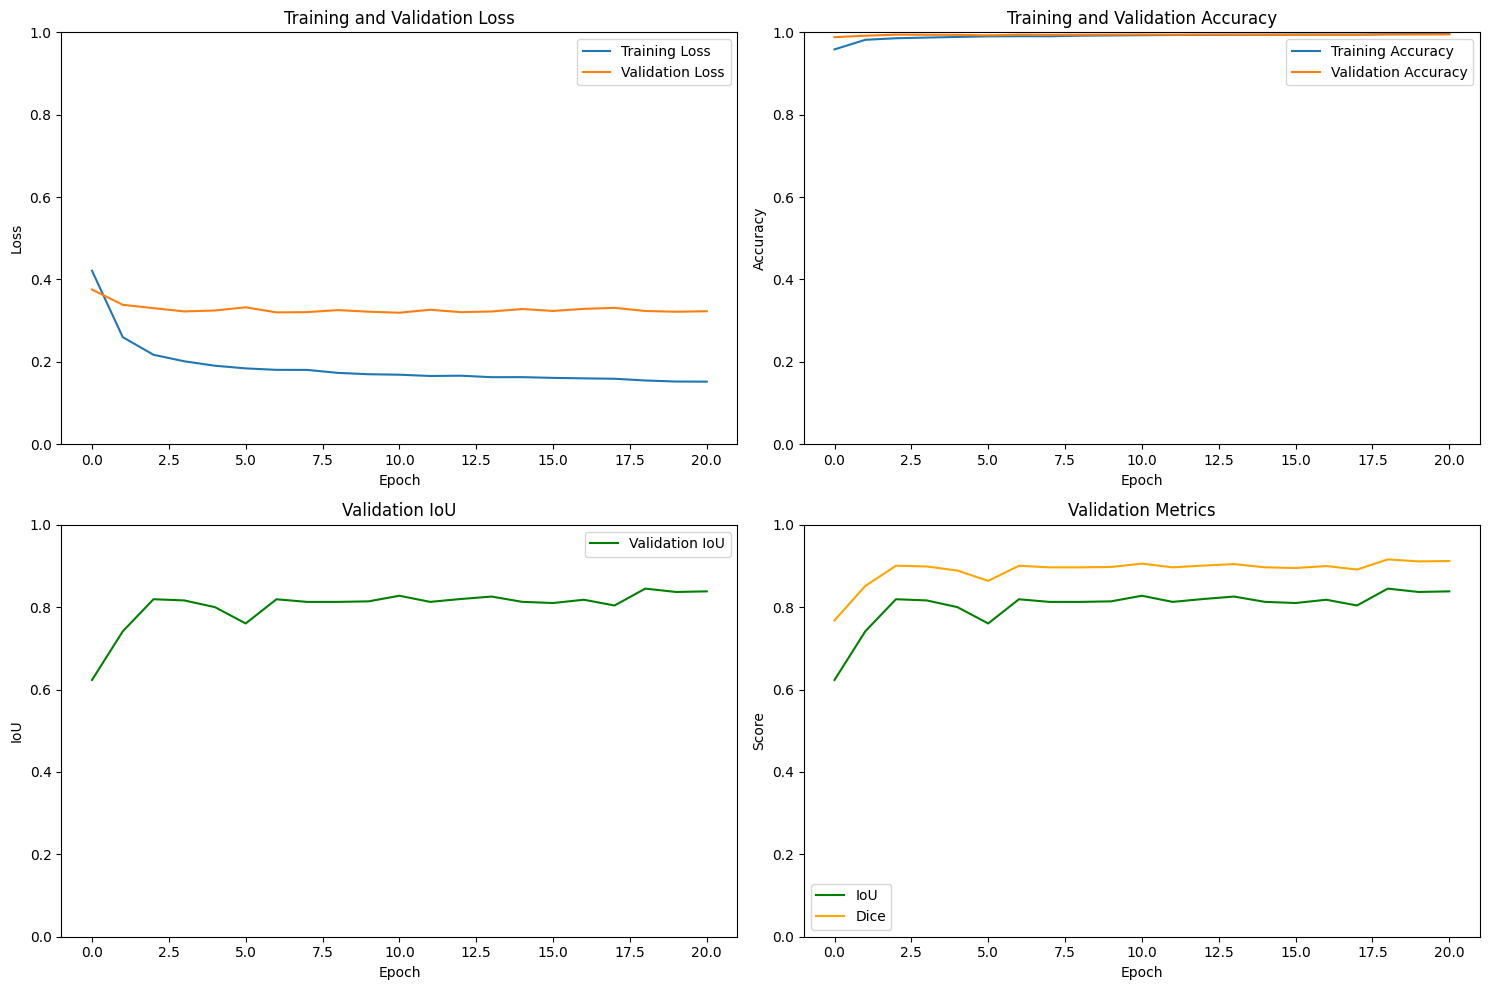

Loading best model for test evaluation...

Evaluating on test set...


Val batch: 100%|██████████| 271/271 [00:07<00:00, 36.21it/s]



SEGFORMER TEST EVALUATION METRICS - MAGNETIC TILES
Test set processed with batch_size=1
Loss:            0.312817
IoU:             0.8475
mIoU:            0.9215
Dice Coefficient: 0.9175
Accuracy:        0.9955
Precision:       0.9091
Recall:          0.9260
F1-Score:        0.9175
Confusion matrix (pixel-level):
[[17237531    44290]
 [   35422   443013]]


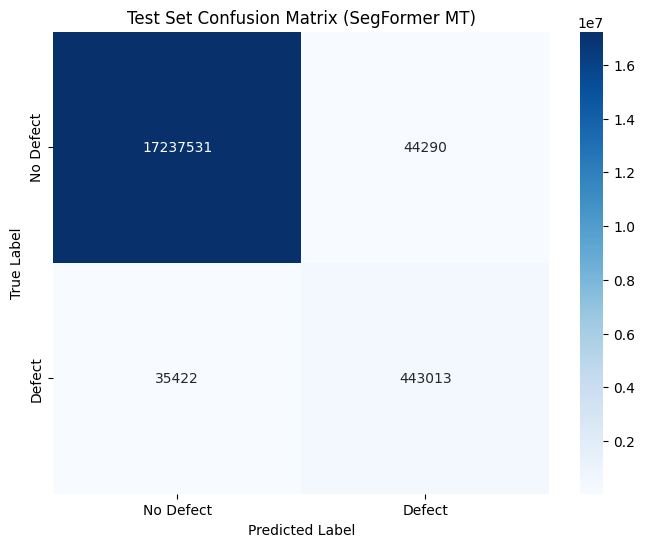

SegFormer Magnetic Tiles training and evaluation completed!


In [21]:
def main():
    BATCH_SIZE = 6
    LEARNING_RATE = 2e-4
    NUM_EPOCHS = 200
    PATIENCE = 10
    IMG_SIZE = (256, 256)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    

    root_dir = '/kaggle/input/datasets/dewangchoudhary/magnetic-tile-dataset/MagneticTilesDataset_Augmented'
    
    train_dataset = MagneticTilesDataset(root_dir, split='train', transform=transform, img_size=IMG_SIZE)
    val_dataset = MagneticTilesDataset(root_dir, split='val', transform=transform, img_size=IMG_SIZE)
    test_dataset = MagneticTilesDataset(root_dir, split='test', transform=transform, img_size=IMG_SIZE)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    # SegFormer model using HuggingFace transformers
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/mit-b0",
        num_labels=1,
        ignore_mismatched_sizes=True
    ).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    print("Starting training...")
    train_losses, train_accs, val_losses, val_accs, val_ious, val_dices = train_model(
        model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, PATIENCE
    )
    
    # Plot training curves
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_ylim(0, 1)
    ax1.legend()
    ax1.set_title('Training and Validation Loss')
    
    ax2.plot(train_accs, label='Training Accuracy')
    ax2.plot(val_accs, label='Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.set_title('Training and Validation Accuracy')
    
    ax3.plot(val_ious, label='Validation IoU', color='green')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('IoU')
    ax3.set_ylim(0, 1)
    ax3.legend()
    ax3.set_title('Validation IoU')
    
    ax4.plot(val_ious, label='IoU', color='green')
    ax4.plot(val_dices, label='Dice', color='orange')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Score')
    ax4.set_ylim(0, 1)
    ax4.legend()
    ax4.set_title('Validation Metrics')
    
    plt.tight_layout()
    plt.savefig('training_curves_segformer_mt.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Test evaluation
    print("Loading best model for test evaluation...")
    model.load_state_dict(torch.load('best_segformer_mt.pth', map_location=device))
    model.to(device)
    
    print("\nEvaluating on test set...")
    test_metrics = validate(model, test_loader)
    
    print("\n" + "="*50)
    print("SEGFORMER TEST EVALUATION METRICS - MAGNETIC TILES")
    print("="*50)
    print(f"Test set processed with batch_size=1")
    print(f"Loss:            {test_metrics['loss']:.6f}")
    print(f"IoU:             {test_metrics['iou']:.4f}")
    print(f"mIoU:            {test_metrics['miou']:.4f}")
    print(f"Dice Coefficient: {test_metrics['dice']:.4f}")
    print(f"Accuracy:        {test_metrics['acc']:.4f}")
    print(f"Precision:       {test_metrics['precision']:.4f}")
    print(f"Recall:          {test_metrics['recall']:.4f}")
    print(f"F1-Score:        {test_metrics['f1']:.4f}")
    print("Confusion matrix (pixel-level):")
    print(test_metrics["confusion"])
    print("="*50)
    
    plot_confusion_matrix(test_metrics["confusion"], "Test Set Confusion Matrix (SegFormer MT)")
    
    print("SegFormer Magnetic Tiles training and evaluation completed!")


if __name__ == "__main__":
    main()